# Generation Cost Analysis

This notebook analyzes generation timings for the paired dataset pipeline.

Each CSV row corresponds to one sampled location.

The notebook produces:

1. A stacked barplot showing `pipeline_time` and overhead.
2. A bar chart showing the average percentage contribution of the three pipeline phases.


In [1]:
!mamba install pandas matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.44129999999981373 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
csv_path = Path("100_execution_time.csv")
df = pd.read_csv(csv_path)

df.columns = [c.strip() for c in df.columns]

df.head()

,location_id,scenario_counter,x,y,global_time,scene_sampling_time,semantic_scene_construction_time,condition_wise_rendering_time,pipeline_time
0,0,283169,1207.286887,-335.324057,34.154359,0.000374,5.228785,22.451330,27.680494
1,1,1085115,1259.077056,-400.041021,64.644228,0.000290,3.776643,23.165917,26.942854
2,2,822340,-1061.683327,-687.016475,97.427306,0.000302,7.437150,22.123752,29.561209
3,3,2671938,1150.345255,-1969.991153,136.933032,0.000351,11.818029,24.388873,36.207262
4,4,26157,-916.957043,602.162912,169.935379,0.000352,6.141361,22.982146,29.123867


In [4]:
global_per_location = []
prev_global = None

for _, row in df.iterrows():
    current_global = row["global_time"]
    loc_id = row["location_id"]

    if loc_id == 0 or prev_global is None:
        global_per_location.append(current_global)
    else:
        global_per_location.append(current_global - prev_global)

    prev_global = current_global

df["global_time_per_location"] = global_per_location
df["location_index"] = np.arange(1, len(df) + 1)

df[["location_id", "location_index", "global_time", "global_time_per_location", "pipeline_time"]].head(10)

,location_id,location_index,global_time,global_time_per_location,pipeline_time
0,0,1,34.154359,34.154359,27.680494
1,1,2,64.644228,30.489870,26.942854
2,2,3,97.427306,32.783077,29.561209
3,3,4,136.933032,39.505726,36.207262
4,4,5,169.935379,33.002347,29.123867
5,5,6,201.252776,31.317397,27.385840
6,6,7,239.284672,38.031896,34.320207
7,7,8,272.555952,33.271280,29.604309
8,8,9,306.582603,34.026651,31.168188
9,9,10,339.709692,33.127089,29.041684


## Compute overhead

The overhead is computed as:

```python
overhead_time = corrected_global_time - pipeline_time
```

Tiny negative values, if present, are clipped only for visualization.


In [5]:
df["overhead_time"] = df["global_time_per_location"] - df["pipeline_time"]
df["overhead_time_clipped"] = df["overhead_time"].clip(lower=0)

avg_pipeline = df["pipeline_time"].mean()
avg_overhead = df["overhead_time_clipped"].mean()
avg_total = avg_pipeline + avg_overhead

print(f"Average pipeline time: {avg_pipeline:.3f} s")
print(f"Average overhead time: {avg_overhead:.3f} s")
print(f"Average total time: {avg_total:.3f} s")

Average pipeline time: 29.790 s
Average overhead time: 4.008 s
Average total time: 33.798 s


## Stacked barplot: pipeline time + overhead

Each bar corresponds to one location. The lower portion is the measured pipeline time, while the upper portion is the overhead.

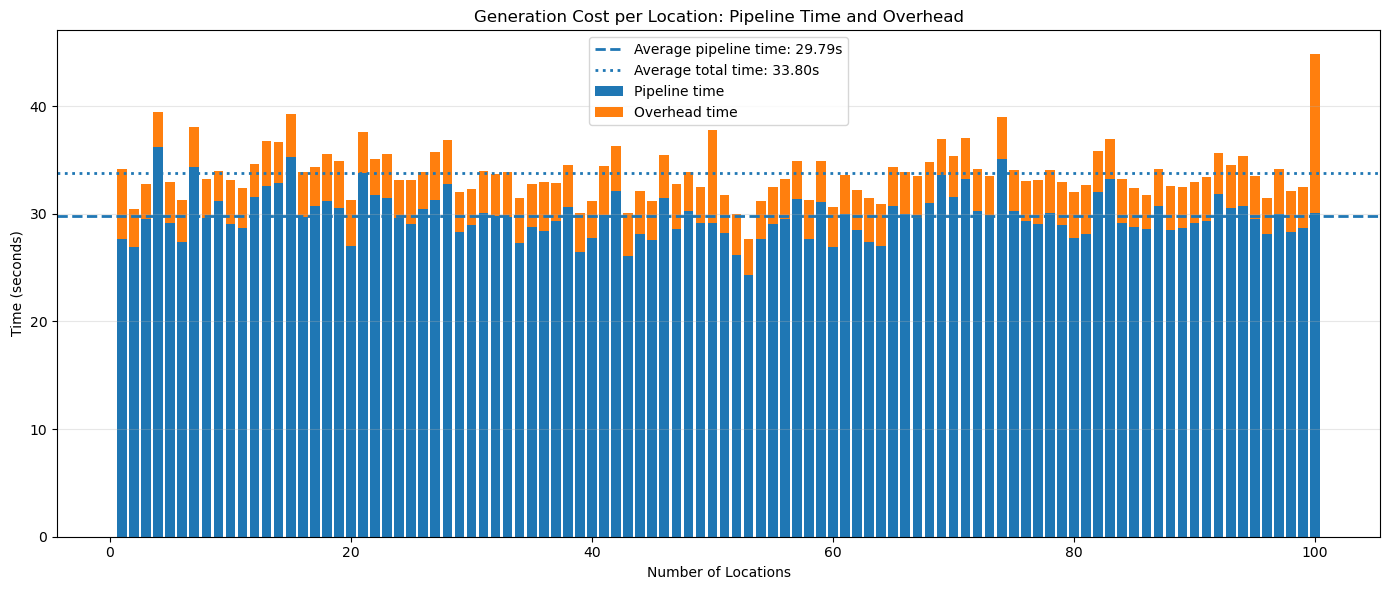

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    df["location_index"],
    df["pipeline_time"],
    label="Pipeline time"
)

ax.bar(
    df["location_index"],
    df["overhead_time_clipped"],
    bottom=df["pipeline_time"],
    label="Overhead time"
)

ax.axhline(
    avg_pipeline,
    linestyle="--",
    linewidth=2,
    label=f"Average pipeline time: {avg_pipeline:.2f}s"
)

ax.axhline(
    avg_pipeline + avg_overhead,
    linestyle=":",
    linewidth=2,
    label=f"Average total time: {(avg_pipeline + avg_overhead):.2f}s"
)

ax.set_xlabel("Number of Locations")
ax.set_ylabel("Time (seconds)")
ax.set_title("Generation Cost per Location: Pipeline Time and Overhead")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig("generation_cost_stacked_barplot.pdf", bbox_inches="tight")
fig.savefig("generation_cost_stacked_barplot.png", dpi=200, bbox_inches="tight")

plt.show()

## Average phase contribution

This plot shows the average percentage contribution of each pipeline phase:

1. `scene_sampling_time`
2. `semantic_scene_construction_time`
3. `condition_wise_rendering_time`


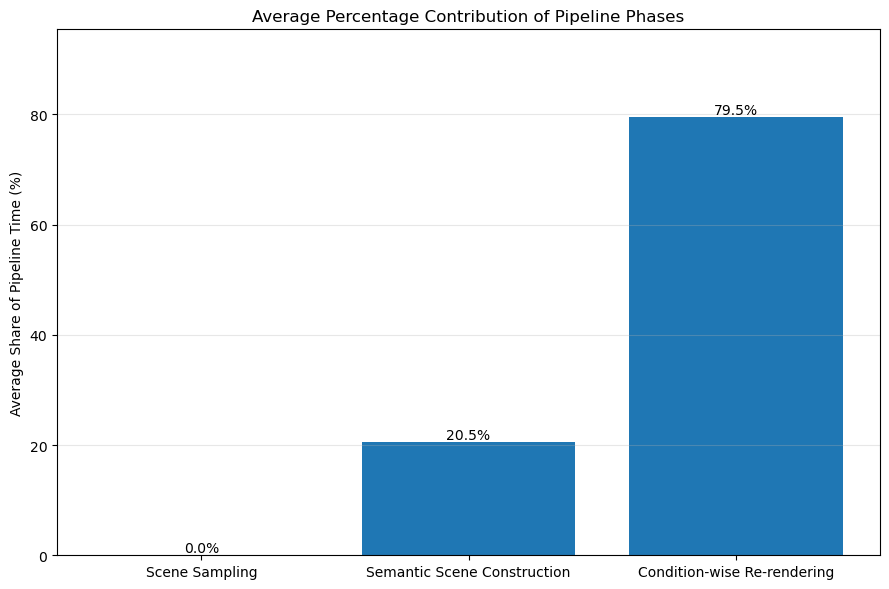

In [7]:
phase_cols = [
    "scene_sampling_time",
    "semantic_scene_construction_time",
    "condition_wise_rendering_time"
]

phase_means = df[phase_cols].mean()
phase_percentages = phase_means / phase_means.sum() * 100

phase_labels = [
    "Scene Sampling",
    "Semantic Scene Construction",
    "Condition-wise Re-rendering"
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(phase_labels, phase_percentages.values)

ax.set_ylabel("Average Share of Pipeline Time (%)")
ax.set_title("Average Percentage Contribution of Pipeline Phases")
ax.set_ylim(0, max(phase_percentages.values) * 1.2)

for bar, value in zip(bars, phase_percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig("pipeline_phase_percentage_histogram.pdf", bbox_inches="tight")
fig.savefig("pipeline_phase_percentage_histogram.png", dpi=200, bbox_inches="tight")

plt.show()

## Save processed CSV

In [8]:
#df.to_csv("100_execution_time_processed.csv", index=False)